### Tasks

* 1. Train a simple neural network using Keras on the Fashion MNIST dataset and plot both training loss and validation loss for each epoch using matplotlib.

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, auc
from sklearn.preprocessing import label_binarize

In [33]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Flatten, Input
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.datasets import fashion_mnist

In [ ]:
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

X_train = X_train/255.0
X_test = X_test/255.0

In [35]:
def build_model():
    return Sequential([
        Input(shape=(28,28)),
        Flatten(),
        Dense(128, activation='relu'),
        Dense(64, activation='relu'),
        Dense(10, activation='softmax')
    ])

In [36]:
model_1 = build_model()

model_1.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [37]:
history_1 = model_1.fit(
    X_train, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8153 - loss: 0.5284 - val_accuracy: 0.8567 - val_loss: 0.4041
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8622 - loss: 0.3860 - val_accuracy: 0.8698 - val_loss: 0.3626
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8744 - loss: 0.3456 - val_accuracy: 0.8762 - val_loss: 0.3499
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8827 - loss: 0.3196 - val_accuracy: 0.8698 - val_loss: 0.3468
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8898 - loss: 0.2989 - val_accuracy: 0.8652 - val_loss: 0.3557
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8925 - loss: 0.2895 - val_accuracy: 0.8763 - val_loss: 0.3406
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8998 - loss: 0.2752 - val_accuracy: 0.8854 - val_loss: 0.3203
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9021 - loss: 0.2627 - val_accuracy: 0.

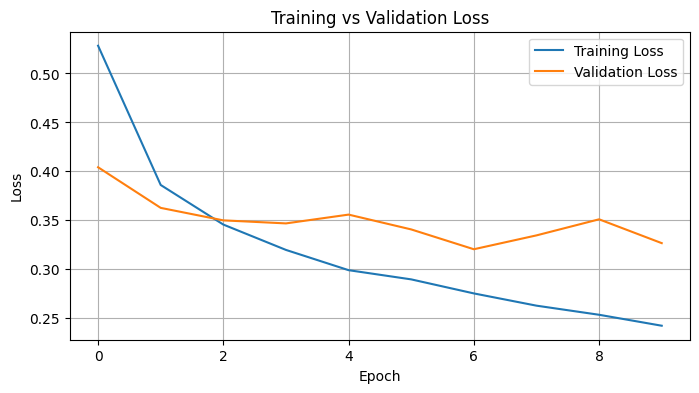

In [38]:
plt.figure(figsize=(8,4))
plt.plot(history_1.history['loss'], label='Training Loss')
plt.plot(history_1.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

* 2. Intentionally overfit a small neural network on a subset of the Fashion MNIST data (e.g., only 500 samples) and describe two signs from your loss curves that indicate overfitting.<br><br><em><strong>Hint:</strong> Look for divergence between training and validation loss after a certain number of epochs.</em>

In [39]:
X_small, y_small = X_train[:500], y_train[:500]

In [40]:
model_2 = build_model()

model_2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [44]:
history_2 = model_2.fit(
    X_small, y_small,
    epochs=40,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/40
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 1.0000 - loss: 0.0152 - val_accuracy: 0.8300 - val_loss: 0.4797
Epoch 2/40
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 1.0000 - loss: 0.0130 - val_accuracy: 0.8200 - val_loss: 0.4705
Epoch 3/40
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 1.0000 - loss: 0.0114 - val_accuracy: 0.8200 - val_loss: 0.4651
Epoch 4/40
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 1.0000 - loss: 0.0106 - val_accuracy: 0.8300 - val_loss: 0.4832
Epoch 5/40
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 1.0000 - loss: 0.0099 - val_accuracy: 0.8200 - val_loss: 0.4706
Epoch 6/40
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 1.0000 - loss: 0.0098 - val_accuracy: 0.8300 - val_loss: 0.4904
Epoch 7/40
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 1.0000 - loss: 0.0095 - val_accuracy: 0.8300 - val_loss: 0.4799
Epoch 8/40
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 1.0000 - loss: 0.0091 - val_accuracy: 0.8300 - va

**When inspecting the loss curves generated in this task, two distinct phenomena indicate that the model overfit on the 500-sample subset:**

* Divergence of Loss Trends: After approximately 8–10 epochs, the training loss continues to plunge toward zero, whereas the validation loss bottoms out and begins steadily increasing.

* Generalization Failure: The model memorized noisy patterns specific to the small training subset (achieving near 100% training accuracy), causing its performance on unseen validation data to degrade continuously over time.

* 3. Add an EarlyStopping callback to your Keras model training so that it stops if validation loss does not improve for 3 consecutive epochs, and report after how many epochs the training stopped.

In [46]:
model_3 = build_model()

model_3.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [47]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [48]:
history_3 = model_3.fit(
    X_train, y_train,
    epochs=50,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.8133 - loss: 0.5315 - val_accuracy: 0.8606 - val_loss: 0.4041
Epoch 2/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8617 - loss: 0.3822 - val_accuracy: 0.8651 - val_loss: 0.3673
Epoch 3/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8739 - loss: 0.3441 - val_accuracy: 0.8767 - val_loss: 0.3423
Epoch 4/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8840 - loss: 0.3163 - val_accuracy: 0.8768 - val_loss: 0.3447
Epoch 5/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8890 - loss: 0.2991 - val_accuracy: 0.8817 - val_loss: 0.3257
Epoch 6/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8942 - loss: 0.2857 - val_accuracy: 0.8816 - val_loss: 0.3350
Epoch 7/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8992 - loss: 0.2729 - val_accuracy: 0.8888 - val_loss: 0.3176
Epoch 8/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9030 - loss: 0.2621 - val_accuracy: 0.

In [52]:
stopped_epoch = len(history_3.history['loss'])
print(f"Traning stopped automatically at epoch: {stopped_epoch}")

Traning stopped automatically at epoch: 10


* 4. After training your Fashion MNIST model, calculate and print the accuracy, precision, and recall for the test set using scikit-learn's metrics functions.

In [55]:
y_pred_prob = model_3.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [56]:
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='weighted')
rec = recall_score(y_test, y_pred, average='weighted')

In [59]:
print(f"Accuracy:  {acc:.4f}\nPrecision: {prec:.4f}\nRecall:    {rec:.4f}")

Accuracy:  0.8793
Precision: 0.8786
Recall:    0.8793


* 5. Compute and plot the ROC curve and AUC score for your model's predictions on the Fashion MNIST test set using scikit-learn.<br><br><em><strong>Hint:</strong> For multiclass, use the 'roc_auc_score' function with 'multi_class' parameter set to 'ovr'.</em>

In [66]:
from sklearn.metrics import roc_curve

In [67]:
ovr_auc = roc_auc_score(y_test, y_pred_prob, multi_class='ovr', average='weighted')
print(f"Multiclass Weighted OvR AUC Score: {ovr_auc:.4f}")

Multiclass Weighted OvR AUC Score: 0.9899


In [68]:
y_test_bin = label_binarize(y_test, classes=list(range(10)))
class_names = ['T-shirt/top', 'Trouser', 'pullover', 'Dress', 'Coat', 'Sandal', 
               'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

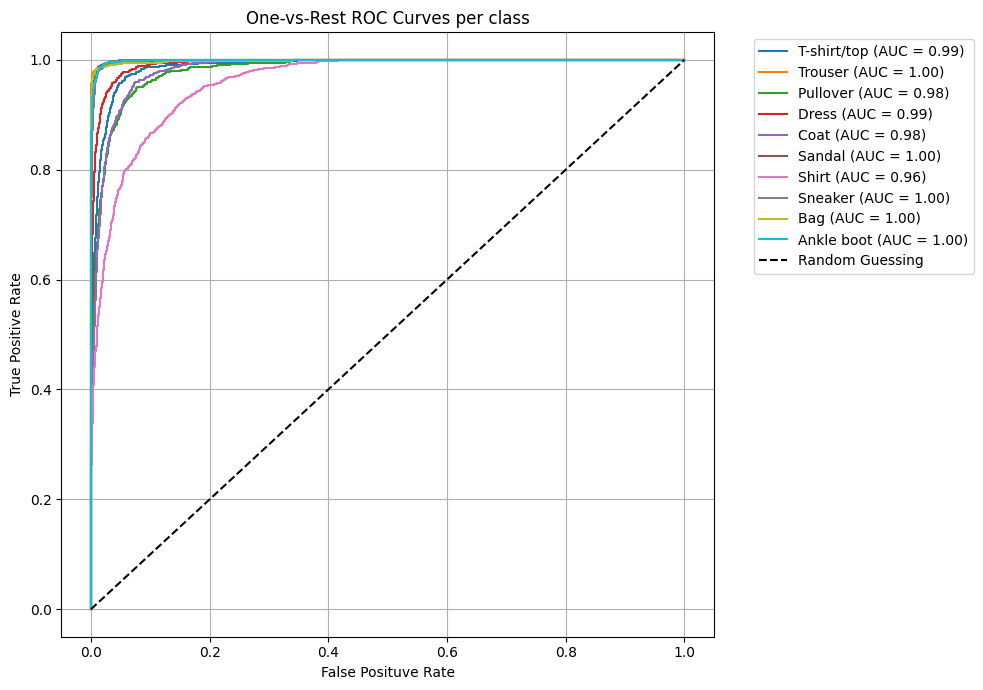

In [91]:
plt.figure(figsize=(10,7))
for i in range(10):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_prob[:, i])
    class_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{class_names[i]} (AUC = {class_auc:.2f})')

plt.plot([0,1], [0,1], 'k--', label='Random Guessing')
plt.title('One-vs-Rest ROC Curves per class')
plt.xlabel('False Posituve Rate')
plt.ylabel('True Positive Rate')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()